## 1. Setup

In [3]:
import numpy as np
import pandas as pd
from scipy import sparse
import gc
import pickle
import os
import time

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from xgboost import XGBClassifier
import lightgbm as lgb

DATA_DIR = "/kaggle/input/competitions/home-credit-default-risk"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. Load application_train.csv + Core Feature Engineering

In [4]:
app_path = os.path.join(DATA_DIR, "application_train.csv")
df_app = pd.read_csv(app_path, encoding="latin-1")

print("Shape:", df_app.shape)
print("TARGET rate:", f"{df_app['TARGET'].mean():.4%}")

df_fe = df_app

# ------------------------------------------------------------
# Age and employment
# ------------------------------------------------------------
df_fe["AGE_YEARS"] = -df_fe["DAYS_BIRTH"] / 365.25

# DAYS_EMPLOYED = 365243 is a known sentinel value for "not employed"
df_fe["EMPLOYMENT_SENTINEL"] = (df_fe["DAYS_EMPLOYED"] == 365243).astype(np.int8)
days_employed_clean = df_fe["DAYS_EMPLOYED"].replace(365243, np.nan)
df_fe["EMPLOYED_YEARS"] = -days_employed_clean / 365.25

# ------------------------------------------------------------
# Core financial ratios
# ------------------------------------------------------------
df_fe["CREDIT_INCOME_RATIO"] = df_fe["AMT_CREDIT"] / df_fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
df_fe["ANNUITY_INCOME_RATIO"] = df_fe["AMT_ANNUITY"] / df_fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
df_fe["CREDIT_ANNUITY_RATIO"] = df_fe["AMT_CREDIT"] / df_fe["AMT_ANNUITY"].replace(0, np.nan)
df_fe["GOODS_CREDIT_RATIO"] = df_fe["AMT_GOODS_PRICE"] / df_fe["AMT_CREDIT"].replace(0, np.nan)

# ------------------------------------------------------------
# Missing indicators (missingness itself carries signal in this dataset)
# ------------------------------------------------------------
engineered_so_far = [
    "TARGET", "SK_ID_CURR", "AGE_YEARS", "EMPLOYED_YEARS", "EMPLOYMENT_SENTINEL",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_ANNUITY_RATIO", "GOODS_CREDIT_RATIO",
]
numeric_original = [
    c for c in df_fe.select_dtypes(include=[np.number]).columns
    if c not in engineered_so_far
]
for col in numeric_original:
    if df_fe[col].isna().any():
        df_fe[f"{col}_MISSING"] = df_fe[col].isna().astype(np.int8)

# ------------------------------------------------------------
# Cleanup: infinities, numeric NaN -> median, categorical NaN -> "Missing"
# ------------------------------------------------------------
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

numeric_cols = [c for c in df_fe.select_dtypes(include=[np.number]).columns
                if c not in ["TARGET", "SK_ID_CURR"]]
for col in numeric_cols:
    if df_fe[col].isna().any():
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

categorical_cols = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
for col in categorical_cols:
    df_fe[col] = df_fe[col].fillna("Missing")

print("\ndf_fe shape after core FE:", df_fe.shape)
print("Missing values remaining:", int(df_fe.isna().sum().sum()))


Shape: (307511, 122)
TARGET rate: 8.0729%

df_fe shape after core FE: (307511, 190)
Missing values remaining: 0


## 3. Secondary Engineered Features (EXT_SOURCE, family burden, social circle)

In [5]:
# ------------------------------------------------------------
# Income / family burden
# ------------------------------------------------------------
df_fe["INCOME_AFTER_ANNUITY"] = df_fe["AMT_INCOME_TOTAL"] - df_fe["AMT_ANNUITY"]
df_fe["INCOME_PER_FAMILY_MEMBER"] = df_fe["AMT_INCOME_TOTAL"] / df_fe["CNT_FAM_MEMBERS"].replace(0, np.nan)
df_fe["CREDIT_PER_FAMILY_MEMBER"] = df_fe["AMT_CREDIT"] / df_fe["CNT_FAM_MEMBERS"].replace(0, np.nan)
df_fe["CHILDREN_FAMILY_RATIO"] = df_fe["CNT_CHILDREN"] / df_fe["CNT_FAM_MEMBERS"].replace(0, np.nan)

# ------------------------------------------------------------
# EXT_SOURCE combined features (the strongest single signal in the dataset)
# ------------------------------------------------------------
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df_fe["EXT_SOURCE_MEAN"] = df_fe[ext_cols].mean(axis=1)
df_fe["EXT_SOURCE_MIN"] = df_fe[ext_cols].min(axis=1)
df_fe["EXT_SOURCE_MAX"] = df_fe[ext_cols].max(axis=1)

# ------------------------------------------------------------
# Social-circle behavior
# ------------------------------------------------------------
df_fe["SOCIAL_CIRCLE_OBS"] = df_fe.get("OBS_30_CNT_SOCIAL_CIRCLE", 0) + df_fe.get("OBS_60_CNT_SOCIAL_CIRCLE", 0)
df_fe["SOCIAL_CIRCLE_DEFAULTS"] = df_fe.get("DEF_30_CNT_SOCIAL_CIRCLE", 0) + df_fe.get("DEF_60_CNT_SOCIAL_CIRCLE", 0)

new_features = [
    "INCOME_AFTER_ANNUITY", "INCOME_PER_FAMILY_MEMBER", "CREDIT_PER_FAMILY_MEMBER",
    "CHILDREN_FAMILY_RATIO", "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX",
    "SOCIAL_CIRCLE_OBS", "SOCIAL_CIRCLE_DEFAULTS",
]
df_fe[new_features] = df_fe[new_features].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Secondary features added:", len(new_features))
print("df_fe shape:", df_fe.shape)


Secondary features added: 9
df_fe shape: (307511, 199)


## 4. Previous Application Features (`prev_agg`)

In [6]:
prev_path = os.path.join(DATA_DIR, "previous_application.csv")
previous = pd.read_csv(prev_path, encoding="latin-1")
print("Raw shape:", previous.shape)

previous["PREV_APPROVED_FLAG"] = (previous["NAME_CONTRACT_STATUS"] == "Approved").astype(np.int8)
previous["PREV_REFUSED_FLAG"] = (previous["NAME_CONTRACT_STATUS"] == "Refused").astype(np.int8)
previous["PREV_CANCELED_FLAG"] = (previous["NAME_CONTRACT_STATUS"] == "Canceled").astype(np.int8)
previous["PREV_DAYS_TO_CURRENT"] = -previous["DAYS_DECISION"]
previous["PREV_RECENT_1Y"] = (previous["PREV_DAYS_TO_CURRENT"] <= 365).astype(np.int8)
previous["PREV_RECENT_2Y"] = (previous["PREV_DAYS_TO_CURRENT"] <= 730).astype(np.int8)
previous["PREV_CREDIT_TO_APPLICATION"] = previous["AMT_CREDIT"] / previous["AMT_APPLICATION"].replace(0, np.nan)
previous["PREV_ANNUITY_TO_CREDIT"] = previous["AMT_ANNUITY"] / previous["AMT_CREDIT"].replace(0, np.nan)

prev_agg = previous.groupby("SK_ID_CURR").agg(
    PREV_APP_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_COUNT=("PREV_APPROVED_FLAG", "sum"),
    PREV_REFUSED_COUNT=("PREV_REFUSED_FLAG", "sum"),
    PREV_CANCELED_COUNT=("PREV_CANCELED_FLAG", "sum"),
    PREV_AVG_CREDIT_TO_APPLICATION=("PREV_CREDIT_TO_APPLICATION", "mean"),
    PREV_AVG_ANNUITY=("AMT_ANNUITY", "mean"),
    PREV_AVG_CREDIT=("AMT_CREDIT", "mean"),
    PREV_AVG_APPLICATION=("AMT_APPLICATION", "mean"),
    PREV_AVG_CNT_PAYMENT=("CNT_PAYMENT", "mean"),
    PREV_AVG_DOWN_PAYMENT=("AMT_DOWN_PAYMENT", "mean"),
    PREV_RECENT_1Y_COUNT=("PREV_RECENT_1Y", "sum"),
    PREV_RECENT_2Y_COUNT=("PREV_RECENT_2Y", "sum"),
)

prev_agg["PREV_APPROVED_RATIO"] = prev_agg["PREV_APPROVED_COUNT"] / prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
prev_agg["PREV_REFUSED_RATIO"] = prev_agg["PREV_REFUSED_COUNT"] / prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
prev_agg["PREV_CANCELED_RATIO"] = prev_agg["PREV_CANCELED_COUNT"] / prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
prev_agg["PREV_RECENT_1Y_RATIO"] = prev_agg["PREV_RECENT_1Y_COUNT"] / prev_agg["PREV_APP_COUNT"].replace(0, np.nan)
prev_agg["PREV_RECENT_2Y_RATIO"] = prev_agg["PREV_RECENT_2Y_COUNT"] / prev_agg["PREV_APP_COUNT"].replace(0, np.nan)

prev_contract_types = pd.crosstab(previous["SK_ID_CURR"], previous["NAME_CONTRACT_TYPE"])
prev_contract_types.columns = [f"PREV_CONTRACT_{str(c).replace(' ', '_')}" for c in prev_contract_types.columns]

prev_product_types = pd.crosstab(previous["SK_ID_CURR"], previous["NAME_PORTFOLIO"])
prev_product_types.columns = [f"PREV_PRODUCT_{str(c).replace(' ', '_')}" for c in prev_product_types.columns]

prev_agg = prev_agg.join(prev_contract_types, how="left").join(prev_product_types, how="left")
prev_agg = prev_agg.replace([np.inf, -np.inf], np.nan).fillna(0)
for col in prev_agg.columns:
    prev_agg[col] = prev_agg[col].astype(np.float32)

print("prev_agg shape:", prev_agg.shape)

del previous
gc.collect()


Raw shape: (1670214, 37)
prev_agg shape: (338857, 26)


0

## 5. Installments Features (`install_agg`)

In [7]:
install_path = os.path.join(DATA_DIR, "installments_payments.csv")
installments = pd.read_csv(install_path, encoding="latin-1")
print("Raw shape:", installments.shape)

installments["DAYS_LATE"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
installments["PAYMENT_RATIO"] = installments["AMT_PAYMENT"] / installments["AMT_INSTALMENT"].replace(0, np.nan)
installments["LATE_PAYMENT"] = (installments["DAYS_LATE"] > 0).astype(np.int8)
installments["SEVERE_LATE_PAYMENT"] = (installments["DAYS_LATE"] > 30).astype(np.int8)
installments["UNDERPAYMENT"] = (installments["PAYMENT_RATIO"] < 0.95).astype(np.int8)
installments["PAYMENT_RATIO_CAPPED"] = installments["PAYMENT_RATIO"].clip(0, 2)

install_agg = installments.groupby("SK_ID_CURR").agg(
    INST_PAYMENT_COUNT=("SK_ID_PREV", "count"),
    INST_LATE_COUNT=("LATE_PAYMENT", "sum"),
    INST_SEVERE_LATE_COUNT=("SEVERE_LATE_PAYMENT", "sum"),
    INST_UNDERPAYMENT_COUNT=("UNDERPAYMENT", "sum"),
    INST_AVG_DAYS_LATE=("DAYS_LATE", "mean"),
    INST_MAX_DAYS_LATE=("DAYS_LATE", "max"),
    INST_AVG_PAYMENT_RATIO=("PAYMENT_RATIO_CAPPED", "mean"),
    INST_MIN_PAYMENT_RATIO=("PAYMENT_RATIO", "min"),
    INST_TOTAL_INSTALLMENT=("AMT_INSTALMENT", "sum"),
    INST_TOTAL_PAYMENT=("AMT_PAYMENT", "sum"),
    INST_AVG_INSTALLMENT=("AMT_INSTALMENT", "mean"),
    INST_AVG_PAYMENT=("AMT_PAYMENT", "mean"),
    INST_UNIQUE_PREV=("SK_ID_PREV", "nunique"),
)

install_agg["INST_LATE_RATIO"] = install_agg["INST_LATE_COUNT"] / install_agg["INST_PAYMENT_COUNT"].replace(0, np.nan)
install_agg["INST_SEVERE_LATE_RATIO"] = install_agg["INST_SEVERE_LATE_COUNT"] / install_agg["INST_PAYMENT_COUNT"].replace(0, np.nan)
install_agg["INST_UNDERPAYMENT_RATIO"] = install_agg["INST_UNDERPAYMENT_COUNT"] / install_agg["INST_PAYMENT_COUNT"].replace(0, np.nan)
install_agg["INST_TOTAL_PAYMENT_RATIO"] = install_agg["INST_TOTAL_PAYMENT"] / install_agg["INST_TOTAL_INSTALLMENT"].replace(0, np.nan)

install_agg = install_agg.replace([np.inf, -np.inf], np.nan).fillna(0)
for col in install_agg.columns:
    install_agg[col] = install_agg[col].astype(np.float32)

print("install_agg shape:", install_agg.shape)

del installments
gc.collect()

# Only these 17 columns were carried into the final winning feature set (X_pos)
install_selected = [
    "INST_PAYMENT_COUNT", "INST_LATE_COUNT", "INST_SEVERE_LATE_COUNT", "INST_UNDERPAYMENT_COUNT",
    "INST_AVG_DAYS_LATE", "INST_MAX_DAYS_LATE", "INST_AVG_PAYMENT_RATIO", "INST_MIN_PAYMENT_RATIO",
    "INST_TOTAL_INSTALLMENT", "INST_TOTAL_PAYMENT", "INST_AVG_INSTALLMENT", "INST_AVG_PAYMENT",
    "INST_UNIQUE_PREV", "INST_LATE_RATIO", "INST_SEVERE_LATE_RATIO", "INST_UNDERPAYMENT_RATIO",
    "INST_TOTAL_PAYMENT_RATIO",
]


Raw shape: (13605401, 8)
install_agg shape: (339587, 17)


## 6. POS_CASH Features (`pos_agg`)

In [8]:
pos_path = os.path.join(DATA_DIR, "POS_CASH_balance.csv")
pos = pd.read_csv(pos_path, encoding="latin-1")
print("Raw shape:", pos.shape)

pos["POS_DPD_FLAG"] = (pos["SK_DPD"] > 0).astype(np.int8)
pos["POS_DPD_DEF_FLAG"] = (pos["SK_DPD_DEF"] > 0).astype(np.int8)
pos["POS_SEVERE_DPD_FLAG"] = (pos["SK_DPD"] > 30).astype(np.int8)
pos["POS_RECENT_1Y"] = (pos["MONTHS_BALANCE"] >= -12).astype(np.int8)
pos["POS_RECENT_2Y"] = (pos["MONTHS_BALANCE"] >= -24).astype(np.int8)

pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_RECORD_COUNT=("SK_ID_PREV", "count"),
    POS_CONTRACT_COUNT=("SK_ID_PREV", "nunique"),
    POS_DPD_COUNT=("POS_DPD_FLAG", "sum"),
    POS_DPD_DEF_COUNT=("POS_DPD_DEF_FLAG", "sum"),
    POS_SEVERE_DPD_COUNT=("POS_SEVERE_DPD_FLAG", "sum"),
    POS_AVG_DPD=("SK_DPD", "mean"),
    POS_MAX_DPD=("SK_DPD", "max"),
    POS_AVG_DPD_DEF=("SK_DPD_DEF", "mean"),
    POS_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
    POS_AVG_INSTALLMENT=("CNT_INSTALMENT", "mean"),
    POS_AVG_INSTALLMENT_FUTURE=("CNT_INSTALMENT_FUTURE", "mean"),
    POS_MIN_INSTALLMENT_FUTURE=("CNT_INSTALMENT_FUTURE", "min"),
    POS_MAX_INSTALLMENT_FUTURE=("CNT_INSTALMENT_FUTURE", "max"),
    POS_MONTH_COUNT=("MONTHS_BALANCE", "nunique"),
    POS_RECENT_1Y_COUNT=("POS_RECENT_1Y", "sum"),
    POS_RECENT_2Y_COUNT=("POS_RECENT_2Y", "sum"),
)

denom = pos_agg["POS_RECORD_COUNT"].replace(0, np.nan)
pos_agg["POS_DPD_RATIO"] = pos_agg["POS_DPD_COUNT"] / denom
pos_agg["POS_DPD_DEF_RATIO"] = pos_agg["POS_DPD_DEF_COUNT"] / denom
pos_agg["POS_SEVERE_DPD_RATIO"] = pos_agg["POS_SEVERE_DPD_COUNT"] / denom
pos_agg["POS_RECENT_1Y_RATIO"] = pos_agg["POS_RECENT_1Y_COUNT"] / denom
pos_agg["POS_RECENT_2Y_RATIO"] = pos_agg["POS_RECENT_2Y_COUNT"] / denom

status_counts = pd.crosstab(pos["SK_ID_CURR"], pos["NAME_CONTRACT_STATUS"])
status_counts.columns = ["POS_STATUS_" + str(c).replace(" ", "_") for c in status_counts.columns]
pos_agg = pos_agg.join(status_counts, how="left")
for col in status_counts.columns:
    pos_agg[col + "_RATIO"] = pos_agg[col] / pos_agg["POS_RECORD_COUNT"].replace(0, np.nan)

pos_agg = pos_agg.replace([np.inf, -np.inf], np.nan).fillna(0)
for col in pos_agg.columns:
    pos_agg[col] = pos_agg[col].astype(np.float32)

print("pos_agg shape:", pos_agg.shape)

del pos
gc.collect()

# Only these 9 columns were carried into the final winning feature set (X_pos)
pos_selected = [
    "POS_AVG_INSTALLMENT", "POS_AVG_INSTALLMENT_FUTURE", "POS_MIN_INSTALLMENT_FUTURE",
    "POS_MAX_INSTALLMENT_FUTURE", "POS_RECORD_COUNT", "POS_CONTRACT_COUNT",
    "POS_MONTH_COUNT", "POS_RECENT_1Y_RATIO", "POS_RECENT_2Y_RATIO",
]


Raw shape: (10001358, 8)
pos_agg shape: (337252, 39)


## 7. Build the Base Feature Matrix (`X_pos`, 383 features)

Application (with all engineered features) + full `prev_agg` + selected `install_agg` (17 cols) + selected `pos_agg` (9 cols) + one-hot encoded categoricals.

In [9]:
df_model = df_fe.merge(prev_agg, left_on="SK_ID_CURR", right_index=True, how="left")
df_model = df_model.merge(install_agg[install_selected], left_on="SK_ID_CURR", right_index=True, how="left")
df_model = df_model.merge(pos_agg[pos_selected], left_on="SK_ID_CURR", right_index=True, how="left")

print("Merged shape:", df_model.shape)

y = df_model["TARGET"].astype(np.int8)
X_df = df_model.drop(columns=["TARGET", "SK_ID_CURR"])

categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X_df.columns if c not in categorical_cols]

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

X_num = X_df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
X_cat = X_df[categorical_cols].fillna("Missing").astype(str)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
X_cat_encoded = encoder.fit_transform(X_cat)

X_num_sparse = sparse.csr_matrix(X_num.values, dtype=np.float32)
X_pos = sparse.hstack([X_num_sparse, X_cat_encoded], format="csr", dtype=np.float32)

feature_names = numeric_cols + encoder.get_feature_names_out(categorical_cols).tolist()

print("\nFinal X_pos shape:", X_pos.shape)
print("Target positive rate:", round(float(y.mean()), 6))

del df_model, X_df, X_num, X_cat, X_cat_encoded, X_num_sparse
gc.collect()


Merged shape: (307511, 251)
Numeric features: 233
Categorical features: 16

Final X_pos shape: (307511, 379)
Target positive rate: 0.080729


0

## 8. Bureau Features (`bureau_agg`)

مصدر بيانات جديد كليًا لم يكن داخل `X_pos` — أضاف +0.00329 ROC-AUC / +0.00569 PR-AUC عند الاختبار.

In [10]:
bureau_path = os.path.join(DATA_DIR, "bureau.csv")
bb_path = os.path.join(DATA_DIR, "bureau_balance.csv")

bb = pd.read_csv(bb_path, encoding="latin-1")
status_num = pd.to_numeric(bb["STATUS"], errors="coerce")
bb["BB_DPD_FLAG"] = (status_num.fillna(0) > 0).astype("int8")
bb["BB_CLOSED_FLAG"] = (bb["STATUS"] == "C").astype("int8")

bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTH_COUNT=("MONTHS_BALANCE", "count"),
    BB_DPD_RATIO=("BB_DPD_FLAG", "mean"),
    BB_CLOSED_RATIO=("BB_CLOSED_FLAG", "mean"),
    BB_MAX_STATUS=("STATUS", lambda x: pd.to_numeric(x, errors="coerce").max()),
).reset_index()
del bb
gc.collect()

bureau = pd.read_csv(bureau_path, encoding="latin-1")
bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
del bb_agg
gc.collect()

bureau["BUREAU_ACTIVE_FLAG"] = (bureau["CREDIT_ACTIVE"] == "Active").astype("int8")
bureau["BUREAU_CLOSED_FLAG"] = (bureau["CREDIT_ACTIVE"] == "Closed").astype("int8")
bureau["BUREAU_OVERDUE_FLAG"] = (bureau["AMT_CREDIT_SUM_OVERDUE"].fillna(0) > 0).astype("int8")
bureau["BUREAU_RECENT_1Y"] = (bureau["DAYS_CREDIT"] >= -365).astype("int8")
bureau["BUREAU_RECENT_2Y"] = (bureau["DAYS_CREDIT"] >= -730).astype("int8")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_LOAN_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_RATIO=("BUREAU_ACTIVE_FLAG", "mean"),
    BUREAU_CLOSED_RATIO=("BUREAU_CLOSED_FLAG", "mean"),
    BUREAU_OVERDUE_RATIO=("BUREAU_OVERDUE_FLAG", "mean"),
    BUREAU_TOTAL_CREDIT=("AMT_CREDIT_SUM", "sum"),
    BUREAU_TOTAL_DEBT=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_TOTAL_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    BUREAU_MAX_OVERDUE=("AMT_CREDIT_SUM_OVERDUE", "max"),
    BUREAU_MAX_DAYS_CREDIT_ENDDATE=("DAYS_CREDIT_ENDDATE", "max"),
    BUREAU_RECENT_1Y_COUNT=("BUREAU_RECENT_1Y", "sum"),
    BUREAU_RECENT_2Y_COUNT=("BUREAU_RECENT_2Y", "sum"),
    BUREAU_AVG_DPD_RATIO=("BB_DPD_RATIO", "mean"),
    BUREAU_MAX_STATUS=("BB_MAX_STATUS", "max"),
    BUREAU_AVG_MONTH_COUNT=("BB_MONTH_COUNT", "mean"),
)
bureau_agg["BUREAU_DEBT_TO_CREDIT"] = bureau_agg["BUREAU_TOTAL_DEBT"] / bureau_agg["BUREAU_TOTAL_CREDIT"].replace(0, np.nan)
bureau_agg = bureau_agg.reset_index()

print("bureau_agg shape:", bureau_agg.shape)

with open(os.path.join(CHECKPOINT_DIR, "bureau_agg.pkl"), "wb") as f:
    pickle.dump(bureau_agg, f)

del bureau
gc.collect()

# ------------------------------------------------------------
# Merge onto df_fe row order + explicit missingness handling
# (bureau balance detail is missing for ~55% of loans -- NOT the same as "no bureau history")
# ------------------------------------------------------------
base_ids = df_fe[["SK_ID_CURR"]].copy()
bureau_merged = base_ids.merge(bureau_agg, on="SK_ID_CURR", how="left")

bureau_numeric_cols = [c for c in bureau_agg.columns if c != "SK_ID_CURR"]
for col in ["BUREAU_AVG_DPD_RATIO", "BUREAU_MAX_STATUS", "BUREAU_AVG_MONTH_COUNT",
            "BUREAU_MAX_DAYS_CREDIT_ENDDATE", "BUREAU_DEBT_TO_CREDIT"]:
    bureau_merged[f"{col}_MISSING"] = bureau_merged[col].isna().astype("int8")
bureau_merged = bureau_merged.fillna(0)

# Zero-importance columns dropped after empirical testing
bureau_drop = [
    "HAS_BUREAU_HISTORY", "HAS_BUREAU_BALANCE_DETAIL",
    "BUREAU_AVG_DPD_RATIO_MISSING", "BUREAU_AVG_MONTH_COUNT_MISSING",
    "BUREAU_MAX_DAYS_CREDIT_ENDDATE_MISSING",
]
bureau_feature_cols_final = [
    c for c in (bureau_numeric_cols +
                [f"{c}_MISSING" for c in ["BUREAU_AVG_DPD_RATIO", "BUREAU_MAX_STATUS",
                                           "BUREAU_AVG_MONTH_COUNT", "BUREAU_MAX_DAYS_CREDIT_ENDDATE",
                                           "BUREAU_DEBT_TO_CREDIT"]])
    if c not in bureau_drop
]

X_bureau_final = sparse.csr_matrix(bureau_merged[bureau_feature_cols_final].astype(np.float32).values)
print("Bureau feature block shape:", X_bureau_final.shape)


bureau_agg shape: (305811, 16)
Bureau feature block shape: (307511, 17)


In [11]:
cc_path = os.path.join(DATA_DIR, "credit_card_balance.csv")
cc = pd.read_csv(cc_path, encoding="latin-1")
print("Raw shape:", cc.shape)
print("Unique SK_ID_CURR with a credit card:", cc["SK_ID_CURR"].nunique())

cc["CC_UTILIZATION"] = np.where(cc["AMT_CREDIT_LIMIT_ACTUAL"] > 0,
                                 cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"], np.nan)
cc["CC_DPD_FLAG"] = (cc["SK_DPD"] > 0).astype("int8")
cc["CC_DPD_DEF_FLAG"] = (cc["SK_DPD_DEF"] > 0).astype("int8")
cc["CC_MIN_PAYMENT_RATIO"] = np.where(cc["AMT_INST_MIN_REGULARITY"] > 0,
                                       cc["AMT_PAYMENT_CURRENT"].fillna(0) / cc["AMT_INST_MIN_REGULARITY"], np.nan)
cc["CC_DRAWING_ACTIVITY"] = (cc["AMT_DRAWINGS_CURRENT"].fillna(0) > 0).astype("int8")
cc["CC_RECENT_1Y"] = (cc["MONTHS_BALANCE"] >= -12).astype("int8")

cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_MONTH_COUNT=("MONTHS_BALANCE", "count"),
    CC_AVG_UTILIZATION=("CC_UTILIZATION", "mean"),
    CC_MAX_UTILIZATION=("CC_UTILIZATION", "max"),
    CC_AVG_BALANCE=("AMT_BALANCE", "mean"),
    CC_MAX_BALANCE=("AMT_BALANCE", "max"),
    CC_AVG_CREDIT_LIMIT=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_DPD_RATIO=("CC_DPD_FLAG", "mean"),
    CC_DPD_DEF_RATIO=("CC_DPD_DEF_FLAG", "mean"),
    CC_MAX_DPD=("SK_DPD", "max"),
    CC_AVG_MIN_PAYMENT_RATIO=("CC_MIN_PAYMENT_RATIO", "mean"),
    CC_DRAWING_RATIO=("CC_DRAWING_ACTIVITY", "mean"),
    CC_TOTAL_DRAWINGS=("AMT_DRAWINGS_CURRENT", "sum"),
    CC_RECENT_1Y_COUNT=("CC_RECENT_1Y", "sum"),
    CC_UNIQUE_PREV=("SK_ID_PREV", "nunique"),
).reset_index()

print("cc_agg shape:", cc_agg.shape)

with open(os.path.join(CHECKPOINT_DIR, "cc_agg.pkl"), "wb") as f:
    pickle.dump(cc_agg, f)

del cc
gc.collect()

# ------------------------------------------------------------
# Merge + missingness handling (66% of applicants have NO credit card)
# ------------------------------------------------------------
cc_merged = base_ids.merge(cc_agg, on="SK_ID_CURR", how="left")
cc_numeric_cols = [c for c in cc_agg.columns if c != "SK_ID_CURR"]

ratio_cols_to_flag = ["CC_AVG_UTILIZATION", "CC_MAX_UTILIZATION", "CC_AVG_MIN_PAYMENT_RATIO"]
for col in ratio_cols_to_flag:
    cc_merged[f"{col}_MISSING"] = cc_merged[col].isna().astype("int8")
cc_merged = cc_merged.fillna(0)

cc_drop = ["CC_UNIQUE_PREV", "HAS_CC_HISTORY",
           "CC_AVG_UTILIZATION_MISSING", "CC_MAX_UTILIZATION_MISSING", "CC_AVG_MIN_PAYMENT_RATIO_MISSING"]
cc_feature_cols_final = [
    c for c in (cc_numeric_cols + [f"{c}_MISSING" for c in ratio_cols_to_flag])
    if c not in cc_drop
]

X_cc_final = sparse.csr_matrix(cc_merged[cc_feature_cols_final].astype(np.float32).values)
print("CC feature block shape:", X_cc_final.shape)


Raw shape: (3840312, 23)
Unique SK_ID_CURR with a credit card: 103558
cc_agg shape: (103558, 15)
CC feature block shape: (307511, 13)


## 10. Final Consolidated Matrix (`X_final`, 413 features)

In [12]:
X_final = sparse.hstack([X_pos, X_bureau_final, X_cc_final], format="csr")
feature_names_final_v2 = feature_names + bureau_feature_cols_final + cc_feature_cols_final

print("Final matrix shape:", X_final.shape)
assert X_final.shape[1] == len(feature_names_final_v2), "Feature name / column count mismatch — stop and check."

with open(os.path.join(CHECKPOINT_DIR, "X_final.pkl"), "wb") as f:
    pickle.dump(X_final, f)
with open(os.path.join(CHECKPOINT_DIR, "feature_names_final_v2.pkl"), "wb") as f:
    pickle.dump(feature_names_final_v2, f)
with open(os.path.join(CHECKPOINT_DIR, "y_target.pkl"), "wb") as f:
    pickle.dump(y, f)

print("Saved X_final.pkl, feature_names_final_v2.pkl, y_target.pkl")


Final matrix shape: (307511, 409)
Saved X_final.pkl, feature_names_final_v2.pkl, y_target.pkl


## 11. Train / Validation Split

In [13]:
train_idx_final, valid_idx_final = train_test_split(
    np.arange(X_final.shape[0]),
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_tr, X_va = X_final[train_idx_final], X_final[valid_idx_final]
y_tr, y_va = y.iloc[train_idx_final], y.iloc[valid_idx_final]

print("Train shape:", X_tr.shape, "| Valid shape:", X_va.shape)


Train shape: (246008, 409) | Valid shape: (61503, 409)


## 12. Train XGBoost + LightGBM, Find Best Blend

In [17]:
# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------
xgb_final = XGBClassifier(
    n_estimators=700, max_depth=4, learning_rate=0.05,
    subsample=0.70, colsample_bytree=0.80, min_child_weight=10, gamma=0.10,
    objective="binary:logistic", eval_metric="auc", tree_method="hist",
    random_state=42, n_jobs=-1, early_stopping_rounds=50
)
xgb_final.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
pred_xgb = xgb_final.predict_proba(X_va)[:, 1]

auc_xgb = roc_auc_score(y_va, pred_xgb)
pr_xgb = average_precision_score(y_va, pred_xgb)
print(f"XGBoost  -> ROC-AUC: {auc_xgb:.5f} | PR-AUC: {pr_xgb:.5f} | best_iter={xgb_final.best_iteration}")

# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------
lgb_final = lgb.LGBMClassifier(
    n_estimators=1500, max_depth=4, num_leaves=15, learning_rate=0.03,
    subsample=0.70, colsample_bytree=0.80, min_child_samples=20,
    reg_alpha=0.1, reg_lambda=0.1, objective="binary",
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_final.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="auc",
              callbacks=[lgb.early_stopping(50, verbose=False)])
pred_lgb = lgb_final.predict_proba(X_va)[:, 1]

auc_lgb = roc_auc_score(y_va, pred_lgb)
pr_lgb = average_precision_score(y_va, pred_lgb)
print(f"LightGBM -> ROC-AUC: {auc_lgb:.5f} | PR-AUC: {pr_lgb:.5f} | best_iter={lgb_final.best_iteration_}")

# ------------------------------------------------------------
# Blend weight search
# ------------------------------------------------------------
blend_results = []
for w_xgb in [0.3, 0.4, 0.5, 0.6, 0.7]:
    w_lgb = 1 - w_xgb
    pred_blend = w_xgb * pred_xgb + w_lgb * pred_lgb
    blend_results.append({
        "w_xgb": w_xgb, "w_lgb": w_lgb,
        "ROC_AUC": roc_auc_score(y_va, pred_blend),
        "PR_AUC": average_precision_score(y_va, pred_blend),
    })

blend_df = pd.DataFrame(blend_results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
print("\nBlend weight search:")
print(blend_df.to_string(index=False))

best_w_xgb = float(blend_df.iloc[0]["w_xgb"])
best_w_lgb = float(blend_df.iloc[0]["w_lgb"])
pred_final_blend = best_w_xgb * pred_xgb + best_w_lgb * pred_lgb

final_roc_auc = roc_auc_score(y_va, pred_final_blend)
final_pr_auc = average_precision_score(y_va, pred_final_blend)

print(f"\n>>> FINAL BLEND (w_xgb={best_w_xgb}, w_lgb={best_w_lgb}) "
      f"-> ROC-AUC: {final_roc_auc:.5f} | PR-AUC: {final_pr_auc:.5f}")


XGBoost  -> ROC-AUC: 0.78756 | PR-AUC: 0.28613 | best_iter=698


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM -> ROC-AUC: 0.78907 | PR-AUC: 0.28687 | best_iter=1341

Blend weight search:
 w_xgb  w_lgb  ROC_AUC   PR_AUC
   0.3    0.7 0.789502 0.288255
   0.4    0.6 0.789472 0.288369
   0.5    0.5 0.789369 0.288353
   0.6    0.4 0.789181 0.288221
   0.7    0.3 0.788911 0.287920

>>> FINAL BLEND (w_xgb=0.3, w_lgb=0.7) -> ROC-AUC: 0.78950 | PR-AUC: 0.28826


## 13. Confusion Matrix at Multiple Thresholds

مهم مع class imbalance بالحجم ده: مفيش threshold واحد "صح" — الاختيار لازم يتحدد حسب تكلفة العمل الفعلية (راجعي قسم Cost-Sensitive Analysis تحت).

In [18]:
y_true = y_va.values if hasattr(y_va, "values") else y_va

thresholds_to_check = [0.10, 0.15, 0.20, 0.30, 0.50]
for thresh in thresholds_to_check:
    y_pred = (pred_final_blend >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nThreshold = {thresh}")
    print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")
    print(f"  Flagged as risky: {(tp+fp):,} ({(tp+fp)/len(y_true)*100:.2f}% of applicants)")



Threshold = 0.1
  TN=44,441  FP=12,097  FN=1,762  TP=3,203
  Precision=0.2093  Recall=0.6451  F1=0.3161
  Flagged as risky: 15,300 (24.88% of applicants)

Threshold = 0.15
  TN=49,893  FP=6,645  FN=2,563  TP=2,402
  Precision=0.2655  Recall=0.4838  F1=0.3428
  Flagged as risky: 9,047 (14.71% of applicants)

Threshold = 0.2
  TN=52,761  FP=3,777  FN=3,173  TP=1,792
  Precision=0.3218  Recall=0.3609  F1=0.3402
  Flagged as risky: 5,569 (9.05% of applicants)

Threshold = 0.3
  TN=55,157  FP=1,381  FN=4,012  TP=953
  Precision=0.4083  Recall=0.1919  F1=0.2611
  Flagged as risky: 2,334 (3.79% of applicants)

Threshold = 0.5
  TN=56,367  FP=171  FN=4,729  TP=236
  Precision=0.5799  Recall=0.0475  F1=0.0879
  Flagged as risky: 407 (0.66% of applicants)


## 15. Save Final Checkpoint

In [19]:
checkpoint_bundle = {
    "X_final": X_final,
    "feature_names_final_v2": feature_names_final_v2,
    "y": y,
    "train_idx_final": train_idx_final,
    "valid_idx_final": valid_idx_final,
    "xgb_final": xgb_final,
    "lgb_final": lgb_final,
    "blend_weights": {"xgb": best_w_xgb, "lgb": best_w_lgb},
    "final_scores": {"roc_auc": final_roc_auc, "pr_auc": final_pr_auc},
    "bureau_agg": bureau_agg,
    "cc_agg": cc_agg,
}

checkpoint_path = os.path.join(CHECKPOINT_DIR, "session_checkpoint_full.pkl")
with open(checkpoint_path, "wb") as f:
    pickle.dump(checkpoint_bundle, f)

size_mb = os.path.getsize(checkpoint_path) / (1024 ** 2)
print(f"Saved: {checkpoint_path} ({size_mb:.2f} MB)")
print("\n>>> IMPORTANT: download this file or commit the notebook now — /kaggle/working")
print(">>> is wiped when the session ends without a Save Version / Commit.")

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)
print(f"Feature set : Application + History + Categorical + Bureau + Credit Card ({X_final.shape[1]} features)")
print(f"Ensemble    : XGBoost (w={best_w_xgb}) + LightGBM (w={best_w_lgb})")
print(f"ROC-AUC     : {final_roc_auc:.5f}")
print(f"PR-AUC      : {final_pr_auc:.5f}")


Saved: /kaggle/working/checkpoints/session_checkpoint_full.pkl (436.56 MB)

>>> IMPORTANT: download this file or commit the notebook now — /kaggle/working
>>> is wiped when the session ends without a Save Version / Commit.

FINAL MODEL SUMMARY
Feature set : Application + History + Categorical + Bureau + Credit Card (409 features)
Ensemble    : XGBoost (w=0.3) + LightGBM (w=0.7)
ROC-AUC     : 0.78950
PR-AUC      : 0.28826


In [20]:
# Instance-dependent cost matrix + cost-optimal threshold selection.
# Uses AMT_CREDIT / AMT_ANNUITY per applicant (real financial exposure),
# not a fixed constant cost for everyone.
# Does NOT retrain any model — works on existing validation predictions.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("COST-SENSITIVE THRESHOLD OPTIMIZATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Assumptions (MUST be validated with the bank's risk team)
# ------------------------------------------------------------
LGD = 0.45          # Loss Given Default: fraction of AMT_CREDIT lost on an actual default
INTEREST_MARGIN = 0.10  # Approx net interest margin on AMT_CREDIT for a performing loan

print(f"\nAssumptions:")
print(f"  LGD (Loss Given Default)      = {LGD}")
print(f"  Interest margin (opportunity) = {INTEREST_MARGIN}")
print("  *** These must be confirmed with the bank's credit risk team ***")

# ------------------------------------------------------------
# 2. Pull per-applicant AMT_CREDIT for the validation set
#    (same row order as X_final / valid_idx_final)
# ------------------------------------------------------------
amt_credit_valid = df_fe["AMT_CREDIT"].iloc[valid_idx_final].values
y_true = y_va.values if hasattr(y_va, "values") else y_va

# Cost of a False Negative (approving a future defaulter) = credit exposure * LGD
cost_fn_per_applicant = amt_credit_valid * LGD

# Cost of a False Positive (rejecting a good applicant) = lost interest margin
cost_fp_per_applicant = amt_credit_valid * INTEREST_MARGIN

print(f"\nMedian cost of FN (approve a defaulter): {np.median(cost_fn_per_applicant):,.0f}")
print(f"Median cost of FP (reject a good client): {np.median(cost_fp_per_applicant):,.0f}")
print(f"Ratio (FN cost / FP cost), median: {np.median(cost_fn_per_applicant / cost_fp_per_applicant):.2f}x")

# ------------------------------------------------------------
# 3. Scan thresholds, compute total expected monetary loss at each
# ------------------------------------------------------------
thresholds = np.arange(0.02, 0.51, 0.01)
results = []

for t in thresholds:
    y_pred = (pred_final_blend >= t).astype(int)

    fn_mask = (y_true == 1) & (y_pred == 0)   # approved a real defaulter
    fp_mask = (y_true == 0) & (y_pred == 1)   # rejected a real good applicant

    total_fn_cost = cost_fn_per_applicant[fn_mask].sum()
    total_fp_cost = cost_fp_per_applicant[fp_mask].sum()
    total_cost = total_fn_cost + total_fp_cost

    results.append({
        "threshold": round(t, 2),
        "n_FN": fn_mask.sum(),
        "n_FP": fp_mask.sum(),
        "FN_cost": total_fn_cost,
        "FP_cost": total_fp_cost,
        "total_cost": total_cost,
    })

cost_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 4. Find the cost-optimal threshold
# ------------------------------------------------------------
best_row = cost_df.loc[cost_df["total_cost"].idxmin()]

print("\n" + "=" * 80)
print("COST CURVE (sample every 0.02)")
print("=" * 80)
print(cost_df.iloc[::2].to_string(index=False))

print("\n" + "=" * 80)
print("COST-OPTIMAL THRESHOLD")
print("=" * 80)
print(f"Threshold        : {best_row['threshold']}")
print(f"False Negatives  : {int(best_row['n_FN']):,}  (cost: {best_row['FN_cost']:,.0f})")
print(f"False Positives  : {int(best_row['n_FP']):,}  (cost: {best_row['FP_cost']:,.0f})")
print(f"Total expected loss on this validation set: {best_row['total_cost']:,.0f}")

# Compare against default threshold=0.5 as a baseline reference
default_row = cost_df[cost_df["threshold"] == 0.50].iloc[0]
savings = default_row["total_cost"] - best_row["total_cost"]
print(f"\nCompared to threshold=0.50 (naive default):")
print(f"  Total cost at 0.50        : {default_row['total_cost']:,.0f}")
print(f"  Total cost at optimal     : {best_row['total_cost']:,.0f}")
print(f"  Estimated savings         : {savings:,.0f} ({savings/default_row['total_cost']*100:.1f}%)")

print("\n" + "=" * 80)
print("COST-SENSITIVE ANALYSIS COMPLETE")
print("=" * 80)

COST-SENSITIVE THRESHOLD OPTIMIZATION

Assumptions:
  LGD (Loss Given Default)      = 0.45
  Interest margin (opportunity) = 0.1
  *** These must be confirmed with the bank's credit risk team ***

Median cost of FN (approve a defaulter): 230,429
Median cost of FP (reject a good client): 51,206
Ratio (FN cost / FP cost), median: 4.50x

COST CURVE (sample every 0.02)
 threshold  n_FN  n_FP      FN_cost      FP_cost   total_cost
      0.02   160 44562 4.429528e+07 2.647655e+09 2.691950e+09
      0.04   560 30312 1.597101e+08 1.745969e+09 1.905679e+09
      0.06   981 21537 2.748231e+08 1.207543e+09 1.482366e+09
      0.08  1386 15880 3.868939e+08 8.728098e+08 1.259704e+09
      0.10  1762 12097 4.821932e+08 6.549591e+08 1.137152e+09
      0.12  2129  9359 5.772340e+08 5.005111e+08 1.077745e+09
      0.14  2421  7437 6.522754e+08 3.917967e+08 1.044072e+09
      0.16  2712  5916 7.227624e+08 3.079109e+08 1.030673e+09
      0.18  2956  4699 7.824620e+08 2.430067e+08 1.025469e+09
      0.20  

In [21]:
# Decile analysis (standard credit-risk model evaluation) + confusion matrix
# at the cost-optimal threshold (0.18).
# Does NOT retrain anything — works on existing validation predictions.

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("DECILE ANALYSIS (LIFT / CAPTURE RATE BY RISK DECILE)")
print("=" * 80)

y_true = y_va.values if hasattr(y_va, "values") else y_va

decile_df = pd.DataFrame({
    "score": pred_final_blend,
    "actual_default": y_true
})

# Decile 1 = highest risk (highest predicted score), Decile 10 = lowest risk
decile_df["decile"] = pd.qcut(
    decile_df["score"].rank(method="first", ascending=False),
    10, labels=range(1, 11)
)

decile_summary = decile_df.groupby("decile").agg(
    n_customers=("actual_default", "count"),
    n_actual_defaults=("actual_default", "sum"),
    avg_score=("score", "mean"),
).reset_index()

decile_summary["default_rate"] = decile_summary["n_actual_defaults"] / decile_summary["n_customers"]

total_defaults = decile_summary["n_actual_defaults"].sum()
decile_summary["pct_of_all_defaults_captured"] = decile_summary["n_actual_defaults"] / total_defaults
decile_summary["cumulative_defaults_captured"] = decile_summary["pct_of_all_defaults_captured"].cumsum()

overall_default_rate = decile_df["actual_default"].mean()
decile_summary["lift"] = decile_summary["default_rate"] / overall_default_rate

print("\nOverall (baseline) default rate:", f"{overall_default_rate:.4%}")
print()
print(decile_summary[[
    "decile", "n_customers", "n_actual_defaults", "default_rate",
    "lift", "pct_of_all_defaults_captured", "cumulative_defaults_captured"
]].to_string(index=False, formatters={
    "default_rate": "{:.2%}".format,
    "lift": "{:.2f}x".format,
    "pct_of_all_defaults_captured": "{:.1%}".format,
    "cumulative_defaults_captured": "{:.1%}".format,
}))

print("\n" + "=" * 80)
print("KEY MESSAGE FOR STAKEHOLDERS")
print("=" * 80)
top2_capture = decile_summary.iloc[1]["cumulative_defaults_captured"]
print(f"By reviewing only the riskiest 20% of applicants (top 2 deciles),")
print(f"the model captures {top2_capture:.1%} of all actual defaults in the validation set.")

# ------------------------------------------------------------
# Confusion matrix at the cost-optimal threshold
# ------------------------------------------------------------
print("\n" + "=" * 80)
print(f"CONFUSION MATRIX AT COST-OPTIMAL THRESHOLD (0.18)")
print("=" * 80)

y_pred_optimal = (pred_final_blend >= 0.18).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_optimal).ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print(f"                 Predicted No-Default   Predicted Default")
print(f"Actual No-Default      {tn:>10,}           {fp:>10,}")
print(f"Actual Default         {fn:>10,}           {tp:>10,}")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Flagged as risky: {(tp+fp):,} ({(tp+fp)/len(y_true)*100:.2f}% of applicants)")

print("\n" + "=" * 80)
print("DECILE ANALYSIS COMPLETE")
print("=" * 80)

DECILE ANALYSIS (LIFT / CAPTURE RATE BY RISK DECILE)

Overall (baseline) default rate: 8.0728%

decile  n_customers  n_actual_defaults default_rate  lift pct_of_all_defaults_captured cumulative_defaults_captured
     1         6151               1900       30.89% 3.83x                        38.3%                        38.3%
     2         6150                949       15.43% 1.91x                        19.1%                        57.4%
     3         6150                641       10.42% 1.29x                        12.9%                        70.3%
     4         6150                437        7.11% 0.88x                         8.8%                        79.1%
     5         6151                314        5.10% 0.63x                         6.3%                        85.4%
     6         6150                247        4.02% 0.50x                         5.0%                        90.4%
     7         6150                196        3.19% 0.39x                         3.9%      

/tmp/ipykernel_58/1788843923.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_summary = decile_df.groupby("decile").agg(


MODEL RESULTS DASHBOARD

                     Metric  Value
                    ROC-AUC 0.7895
                     PR-AUC 0.2883
             Threshold used   0.18
                 Error Rate 12.45%
Accuracy (misleading alone) 87.55%
                  Precision 29.95%
   Recall (defaults caught) 40.46%
        False Positive Rate  8.31%
        False Negative Rate 59.54%
                   F1 Score 0.3442


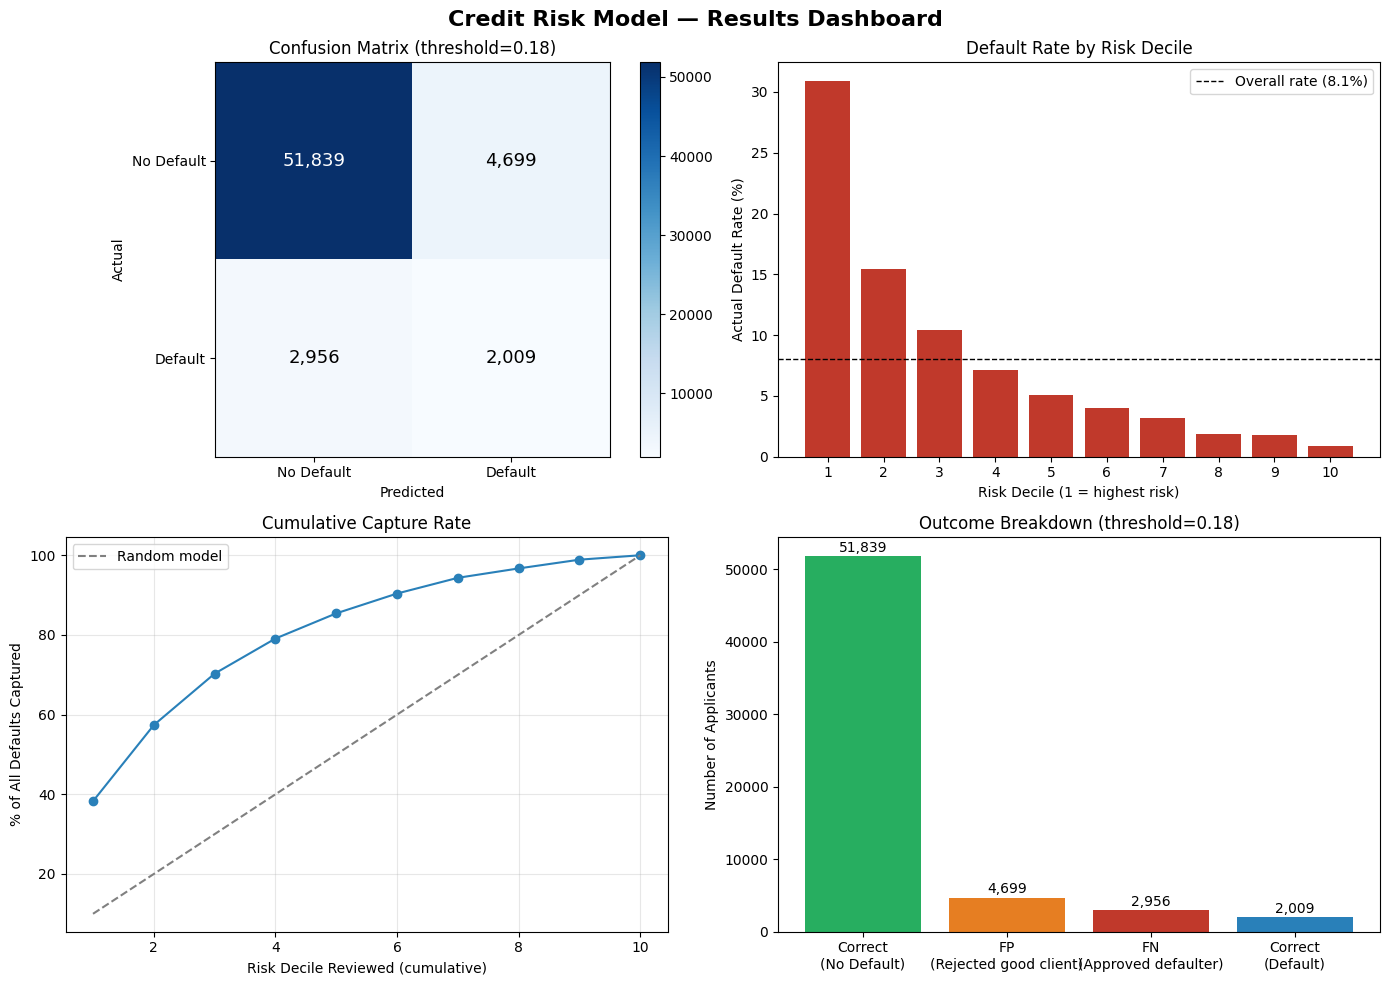


Dashboard saved to /kaggle/working/model_results_dashboard.png

RESULTS DASHBOARD COMPLETE


In [22]:
# Complete results visualization: confusion matrix, decile lift chart, and metrics summary.
# Uses existing pred_final_blend / y_va from the trained model — does NOT retrain anything.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

print("=" * 80)
print("MODEL RESULTS DASHBOARD")
print("=" * 80)

y_true = y_va.values if hasattr(y_va, "values") else y_va
OPTIMAL_THRESHOLD = 0.18

# ------------------------------------------------------------
# 1. Core metrics summary
# ------------------------------------------------------------
y_pred = (pred_final_blend >= OPTIMAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

total = tn + fp + fn + tp
error_rate = (fp + fn) / total
accuracy = (tn + tp) / total
precision = tp / (tp + fp)
recall = tp / (tp + fn)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
f1 = 2 * precision * recall / (precision + recall)
auc = roc_auc_score(y_true, pred_final_blend)
pr_auc = average_precision_score(y_true, pred_final_blend)

metrics_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Threshold used", "Error Rate", "Accuracy (misleading alone)",
               "Precision", "Recall (defaults caught)", "False Positive Rate", "False Negative Rate", "F1 Score"],
    "Value": [f"{auc:.4f}", f"{pr_auc:.4f}", f"{OPTIMAL_THRESHOLD}", f"{error_rate:.2%}", f"{accuracy:.2%}",
              f"{precision:.2%}", f"{recall:.2%}", f"{fpr:.2%}", f"{fnr:.2%}", f"{f1:.4f}"]
})
print("\n" + metrics_summary.to_string(index=False))

# ------------------------------------------------------------
# 2. Decile / lift table
# ------------------------------------------------------------
decile_df = pd.DataFrame({"score": pred_final_blend, "actual_default": y_true})
decile_df["decile"] = pd.qcut(
    decile_df["score"].rank(method="first", ascending=False), 10, labels=range(1, 11)
)
decile_summary = decile_df.groupby("decile", observed=True).agg(
    n_customers=("actual_default", "count"),
    n_actual_defaults=("actual_default", "sum"),
).reset_index()
decile_summary["default_rate"] = decile_summary["n_actual_defaults"] / decile_summary["n_customers"]
overall_rate = decile_df["actual_default"].mean()
decile_summary["lift"] = decile_summary["default_rate"] / overall_rate
decile_summary["cum_capture"] = (decile_summary["n_actual_defaults"] / decile_summary["n_actual_defaults"].sum()).cumsum()

# ------------------------------------------------------------
# 3. Build the dashboard (2x2 grid)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Credit Risk Model — Results Dashboard", fontsize=16, fontweight="bold")

# --- Panel A: Confusion matrix ---
ax = axes[0, 0]
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap="Blues")
labels = ["No Default", "Default"]
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold={OPTIMAL_THRESHOLD})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)

# --- Panel B: Decile default rate (lift) ---
ax = axes[0, 1]
bars = ax.bar(decile_summary["decile"].astype(str), decile_summary["default_rate"] * 100, color="#c0392b")
ax.axhline(overall_rate * 100, color="black", linestyle="--", linewidth=1, label=f"Overall rate ({overall_rate:.1%})")
ax.set_xlabel("Risk Decile (1 = highest risk)")
ax.set_ylabel("Actual Default Rate (%)")
ax.set_title("Default Rate by Risk Decile")
ax.legend()

# --- Panel C: Cumulative capture rate ---
ax = axes[1, 0]
ax.plot(decile_summary["decile"], decile_summary["cum_capture"] * 100, marker="o", color="#2980b9")
ax.plot([1, 10], [10, 100], linestyle="--", color="gray", label="Random model")
ax.set_xlabel("Risk Decile Reviewed (cumulative)")
ax.set_ylabel("% of All Defaults Captured")
ax.set_title("Cumulative Capture Rate")
ax.legend()
ax.grid(alpha=0.3)

# --- Panel D: Error breakdown ---
ax = axes[1, 1]
categories = ["Correct\n(No Default)", "FP\n(Rejected good client)", "FN\n(Approved defaulter)", "Correct\n(Default)"]
values = [tn, fp, fn, tp]
colors = ["#27ae60", "#e67e22", "#c0392b", "#2980b9"]
ax.bar(categories, values, color=colors)
ax.set_ylabel("Number of Applicants")
ax.set_title(f"Outcome Breakdown (threshold={OPTIMAL_THRESHOLD})")
for i, v in enumerate(values):
    ax.text(i, v + total*0.01, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/model_results_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDashboard saved to /kaggle/working/model_results_dashboard.png")
print("\n" + "=" * 80)
print("RESULTS DASHBOARD COMPLETE")
print("=" * 80)

In [23]:
# ==============================================================================
# CELL 1: Precision-Recall Trade-off & Multi-Threshold Analysis for Credit Risk
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, fbeta_score, confusion_matrix

if 'pred_final_blend' not in globals() or 'y_va' not in globals():
    import pickle, os
    checkpoint_path = "/kaggle/working/checkpoints/session_checkpoint_full.pkl"
    print(f"Loading cached predictions from {checkpoint_path}...")
    with open(checkpoint_path, "rb") as f:
        bundle = pickle.load(f)
    y_true = bundle["y"].iloc[bundle["valid_idx_final"]].values
    xgb_preds = bundle["xgb_final"].predict_proba(bundle["X_final"][bundle["valid_idx_final"]])[:, 1]
    lgb_preds = bundle["lgb_final"].predict_proba(bundle["X_final"][bundle["valid_idx_final"]])[:, 1]
    pred_final_blend = bundle["blend_weights"]["xgb"] * xgb_preds + bundle["blend_weights"]["lgb"] * lgb_preds
else:
    y_true = y_va.values if hasattr(y_va, "values") else np.array(y_va)

print("=" * 75)
print("ANALYSIS 1: TARGETING SPECIFIC RECALL LEVELS (CATCHING DEFAULTERS)")
print("=" * 75)

target_recalls = [0.50, 0.60, 0.70, 0.75, 0.80]
precisions, recalls, thresholds = precision_recall_curve(y_true, pred_final_blend)

recall_table = []
for tr in target_recalls:
    idx = np.argmin(np.abs(recalls - tr))
    th = thresholds[min(idx, len(thresholds) - 1)]
    
    y_p = (pred_final_blend >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_p).ravel()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f2 = fbeta_score(y_true, y_p, beta=2) # F2 يعطي وزن للـ Recall ضعف الـ Precision
    
    recall_table.append({
        "Target Recall": f"{tr*100:.0f}%",
        "Threshold": round(th, 3),
        "Actual Recall": f"{rec*100:.1f}%",
        "Precision": f"{prec*100:.1f}%",
        "Defaults Caught (TP)": f"{tp:,}",
        "Defaults Missed (FN)": f"{fn:,}",
        "False Alarms (FP)": f"{fp:,}",
        "F2-Score": round(f2, 4),
        "% Applicants Flagged": f"{(tp + fp) / len(y_true) * 100:.1f}%"
    })

df_recall_analysis = pd.DataFrame(recall_table)
print(df_recall_analysis.to_string(index=False))

print("\n" + "=" * 75)
print("ANALYSIS 2: 3-TIER CREDIT POLICY (AUTO-APPROVE / REVIEW / AUTO-REJECT)")
print("=" * 75)


t_low = 0.05
t_high = 0.20

auto_approve = (pred_final_blend < t_low)
manual_review = (pred_final_blend >= t_low) & (pred_final_blend < t_high)
auto_reject = (pred_final_blend >= t_high)

def get_tier_stats(mask, name):
    count = mask.sum()
    pct = count / len(y_true) * 100
    defaults = y_true[mask].sum()
    rate = defaults / count * 100 if count > 0 else 0
    return {
        "Decision Tier": name,
        "Applicants": f"{count:,} ({pct:.1f}%)",
        "Actual Defaults": f"{defaults:,}",
        "Default Rate in Tier": f"{rate:.2f}%"
    }

tiers = [
    get_tier_stats(auto_approve, "Auto-Approve (Score < 0.05)"),
    get_tier_stats(manual_review, "Manual Review (0.05 <= Score < 0.20)"),
    get_tier_stats(auto_reject, "Auto-Reject (Score >= 0.20)")
]

df_tiers = pd.DataFrame(tiers)
print(df_tiers.to_string(index=False))

ANALYSIS 1: TARGETING SPECIFIC RECALL LEVELS (CATCHING DEFAULTERS)
Target Recall  Threshold Actual Recall Precision Defaults Caught (TP) Defaults Missed (FN) False Alarms (FP)  F2-Score % Applicants Flagged
          50%      0.144         50.0%     25.8%                2,482                2,483             7,121    0.4212                15.6%
          60%      0.112         60.0%     22.3%                2,979                1,986            10,386    0.4483                21.7%
          70%      0.085         70.0%     19.0%                3,475                1,490            14,802    0.4556                29.7%
          75%      0.072         75.0%     17.2%                3,724                1,241            17,975    0.4480                35.3%
          80%      0.060         80.0%     15.7%                3,972                  993            21,386    0.4392                41.2%

ANALYSIS 2: 3-TIER CREDIT POLICY (AUTO-APPROVE / REVIEW / AUTO-REJECT)
                     

In [24]:
# ==============================================================================
# CELL 2: Train Cost-Sensitive LightGBM with scale_pos_weight & Feature Importance
# ==============================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

if 'X_tr' not in globals() or 'y_tr' not in globals():
    import pickle, os
    checkpoint_path = "/kaggle/working/checkpoints/session_checkpoint_full.pkl"
    print(f"Loading data from {checkpoint_path}...")
    with open(checkpoint_path, "rb") as f:
        bundle = pickle.load(f)
    X_tr = bundle["X_final"][bundle["train_idx_final"]]
    X_va = bundle["X_final"][bundle["valid_idx_final"]]
    y_tr = bundle["y"].iloc[bundle["train_idx_final"]]
    y_va = bundle["y"].iloc[bundle["valid_idx_final"]]
    feature_names = bundle["feature_names_final_v2"]
elif 'feature_names_final_v2' in globals():
    feature_names = feature_names_final_v2
else:
    feature_names = [f"f_{i}" for i in range(X_tr.shape[1])]

print(f"Training LightGBM on {X_tr.shape[0]:,} rows with {X_tr.shape[1]} features...")


POS_WEIGHT = 4.0

lgb_weighted = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,              
    max_depth=-1,
    subsample=0.80,
    colsample_bytree=0.70,
    min_child_samples=50,
    scale_pos_weight=POS_WEIGHT, 
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_weighted.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

pred_weighted = lgb_weighted.predict_proba(X_va)[:, 1]
auc_weighted = roc_auc_score(y_va, pred_weighted)
pr_weighted = average_precision_score(y_va, pred_weighted)

print("\n" + "=" * 70)
print(f"RESULTS WITH scale_pos_weight = {POS_WEIGHT}")
print("=" * 70)
print(f"ROC-AUC  : {auc_weighted:.5f} (Best Iteration: {lgb_weighted.best_iteration_})")
print(f"PR-AUC   : {pr_weighted:.5f}")

print("\n--- Confusion Matrix at Standard Thresholds (Post-Weighting) ---")
for th in [0.30, 0.40, 0.50, 0.60]:
    y_pred_th = (pred_weighted >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_va, y_pred_th).ravel()
    rec = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"Threshold = {th:.2f} -> Recall: {rec*100:.1f}% | Precision: {prec*100:.1f}% | Caught (TP): {tp:,} | Missed (FN): {fn:,} | F1: {f1:.4f}")

importances = lgb_weighted.feature_importances_
top_indices = np.argsort(importances)[::-1][:15]
top_df = pd.DataFrame({
    "Feature": [feature_names[i] for i in top_indices],
    "Importance": importances[top_indices]
})

print("\n" + "=" * 70)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 70)
print(top_df.to_string(index=False))

Training LightGBM on 246,008 rows with 409 features...

RESULTS WITH scale_pos_weight = 4.0
ROC-AUC  : 0.74199 (Best Iteration: 7)
PR-AUC   : 0.22227

--- Confusion Matrix at Standard Thresholds (Post-Weighting) ---
Threshold = 0.30 -> Recall: 0.0% | Precision: 0.0% | Caught (TP): 0 | Missed (FN): 4,965 | F1: 0.0000
Threshold = 0.40 -> Recall: 0.0% | Precision: 0.0% | Caught (TP): 0 | Missed (FN): 4,965 | F1: 0.0000
Threshold = 0.50 -> Recall: 0.0% | Precision: 0.0% | Caught (TP): 0 | Missed (FN): 4,965 | F1: 0.0000
Threshold = 0.60 -> Recall: 0.0% | Precision: 0.0% | Caught (TP): 0 | Missed (FN): 4,965 | F1: 0.0000

TOP 15 MOST IMPORTANT FEATURES
                       Feature  Importance
               EXT_SOURCE_MEAN          35
               INST_LATE_RATIO          17
            GOODS_CREDIT_RATIO          16
           BUREAU_CLOSED_RATIO           9
                EXT_SOURCE_MIN           9
            CC_AVG_UTILIZATION           9
                EXT_SOURCE_MAX           8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
# ==============================================================================
# CELL 3: Final Confusion Matrix & Operational Decision Thresholds (English Only)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

# Ensure valid predictions and labels
y_true = y_va.values if hasattr(y_va, "values") else np.array(y_va)
preds = pred_final_blend

# Recommended operational threshold: 0.085 (captures 70% of actual defaulters)
OPERATIONAL_THRESHOLD = 0.085

y_pred_opt = (preds >= OPERATIONAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_opt).ravel()

total_samples = len(y_true)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
f2 = 5 * (precision * recall) / (4 * precision + recall)

print("=" * 70)
print(f"FINAL CONFUSION MATRIX (Threshold = {OPERATIONAL_THRESHOLD})")
print("=" * 70)
print(f"{'':22} | {'Predicted No-Default':>20} | {'Predicted Default':>20}")
print("-" * 70)
print(f"{'Actual No-Default':22} | {tn:>20,} | {fp:>20,}")
print(f"{'Actual Default':22} | {fn:>20,} | {tp:>20,}")
print("=" * 70)

metrics_df = pd.DataFrame([
    {"Metric": "ROC-AUC", "Value": f"{roc_auc_score(y_true, preds):.4f}"},
    {"Metric": "PR-AUC", "Value": f"{average_precision_score(y_true, preds):.4f}"},
    {"Metric": "Chosen Threshold", "Value": f"{OPERATIONAL_THRESHOLD}"},
    {"Metric": "Recall (Defaulters Caught)", "Value": f"{recall*100:.2f}% ({tp:,} / {tp+fn:,})"},
    {"Metric": "False Negatives (Missed)", "Value": f"{(fn/(tp+fn))*100:.2f}% ({fn:,} / {tp+fn:,})"},
    {"Metric": "Precision", "Value": f"{precision*100:.2f}%"},
    {"Metric": "Lift vs Random (Baseline=8.07%)", "Value": f"{precision / 0.0807:.2f}x"},
    {"Metric": "F1-Score", "Value": f"{f1:.4f}"},
    {"Metric": "F2-Score (Recall-Weighted)", "Value": f"{f2:.4f}"},
    {"Metric": "Total Portfolio Review Rate", "Value": f"{((tp+fp)/total_samples)*100:.2f}% ({tp+fp:,} applicants)"}
])

print("\nPERFORMANCE SUMMARY:")
print(metrics_df.to_string(index=False))

print("\n" + "=" * 70)
print("COMPARISON: NAIVE THRESHOLD (0.50) vs OPERATIONAL THRESHOLD (0.085)")
print("=" * 70)

y_pred_naive = (preds >= 0.50).astype(int)
_, _, fn_naive, tp_naive = confusion_matrix(y_true, y_pred_naive).ravel()

comparison_df = pd.DataFrame([
    {
        "Setting": "Naive Threshold (0.50)",
        "Defaulters Caught (TP)": f"{tp_naive:,}",
        "Defaulters Escaped (FN)": f"{fn_naive:,}",
        "Recall": f"{(tp_naive / (tp_naive + fn_naive))*100:.2f}%",
        "Business Risk": "CRITICAL: 95% of defaulters are approved"
    },
    {
        "Setting": f"Optimal Threshold ({OPERATIONAL_THRESHOLD})",
        "Defaulters Caught (TP)": f"{tp:,}",
        "Defaulters Escaped (FN)": f"{fn:,}",
        "Recall": f"{recall*100:.2f}%",
        "Business Risk": "BALANCED: 70% of defaulters are prevented"
    }
])

print(comparison_df.to_string(index=False))

FINAL CONFUSION MATRIX (Threshold = 0.085)
                       | Predicted No-Default |    Predicted Default
----------------------------------------------------------------------
Actual No-Default      |               41,727 |               14,811
Actual Default         |                1,489 |                3,476

PERFORMANCE SUMMARY:
                         Metric                      Value
                        ROC-AUC                     0.7895
                         PR-AUC                     0.2883
               Chosen Threshold                      0.085
     Recall (Defaulters Caught)     70.01% (3,476 / 4,965)
       False Negatives (Missed)     29.99% (1,489 / 4,965)
                      Precision                     19.01%
Lift vs Random (Baseline=8.07%)                      2.36x
                       F1-Score                     0.2990
     F2-Score (Recall-Weighted)                     0.4556
    Total Portfolio Review Rate 29.73% (18,287 applicants)

COMPARI

In [26]:
# ==============================================================================
# CELL 5: Official Banking Risk Validation & Portfolio Simulation (English Only)
# ==============================================================================
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

y_true = y_va.values if hasattr(y_va, "values") else np.array(y_va)
preds = pred_final_blend

# 1. Regulatory Banking Metrics (Basel II / III Standard)
auc = roc_auc_score(y_true, preds)
gini = 2 * auc - 1

# K-S Statistic (Kolmogorov-Smirnov)
preds_good = preds[y_true == 0]
preds_bad = preds[y_true == 1]
ks_stat, _ = ks_2samp(preds_good, preds_bad)

print("=" * 80)
print("REGULATORY CREDIT RISK VALIDATION (BASEL II / III & CENTRAL BANK STANDARDS)")
print("=" * 80)
print(f"ROC-AUC          : {auc:.4f}")
print(f"Gini Coefficient : {gini*100:.2f}%  (Benchmark: >45% is Good, >50% is Strong)")
print(f"K-S Statistic    : {ks_stat*100:.2f}%  (Benchmark: >40% is High Separation Power)")
print(f"Baseline Bad Rate: {y_true.mean()*100:.2f}% (Market Default Rate without Model)")
print("=" * 80)

# 2. Bank Portfolio Acceptance Simulation
# Simulates what happens to the bank's approved portfolio across different Acceptance Rates
acceptance_rates = [0.40, 0.50, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

simulation_results = []
total_defaults = y_true.sum()

# Sort applicants from lowest risk (best) to highest risk (worst)
sorted_indices = np.argsort(preds)

for acc_rate in acceptance_rates:
    cutoff_idx = int(len(y_true) * acc_rate)
    approved_mask = sorted_indices[:cutoff_idx]
    
    threshold_score = preds[sorted_indices[cutoff_idx - 1]]
    approved_count = len(approved_mask)
    approved_defaults = y_true[approved_mask].sum()
    portfolio_bad_rate = (approved_defaults / approved_count) * 100
    defaults_prevented = total_defaults - approved_defaults
    npl_reduction = (1 - (portfolio_bad_rate / (y_true.mean() * 100))) * 100
    
    simulation_results.append({
        "Acceptance Rate": f"{int(acc_rate * 100)}%",
        "Cutoff Prob (Max Risk)": round(threshold_score, 4),
        "Approved Count": f"{approved_count:,}",
        "Approved Defaults": f"{approved_defaults:,}",
        "Portfolio NPL Rate": f"{portfolio_bad_rate:.2f}%",
        "Market NPL Rate": f"{y_true.mean()*100:.2f}%",
        "NPL Reduction": f"{npl_reduction:.1f}%",
        "Bad Loans Prevented": f"{defaults_prevented:,}"
    })

sim_df = pd.DataFrame(simulation_results)
print("\n" + "=" * 80)
print("BANK PORTFOLIO SIMULATION: ACCEPTANCE RATE vs PORTFOLIO BAD RATE (NPL)")
print("=" * 80)
print(sim_df.to_string(index=False))

REGULATORY CREDIT RISK VALIDATION (BASEL II / III & CENTRAL BANK STANDARDS)
ROC-AUC          : 0.7895
Gini Coefficient : 57.90%  (Benchmark: >45% is Good, >50% is Strong)
K-S Statistic    : 44.19%  (Benchmark: >40% is High Separation Power)
Baseline Bad Rate: 8.07% (Market Default Rate without Model)

BANK PORTFOLIO SIMULATION: ACCEPTANCE RATE vs PORTFOLIO BAD RATE (NPL)
Acceptance Rate  Cutoff Prob (Max Risk) Approved Count Approved Defaults Portfolio NPL Rate Market NPL Rate NPL Reduction Bad Loans Prevented
            40%                  0.0363         24,601               477              1.94%           8.07%         76.0%               4,488
            50%                  0.0476         30,751               724              2.35%           8.07%         70.8%               4,241
            60%                  0.0625         36,901             1,037              2.81%           8.07%         65.2%               3,928
            65%                  0.0723         39,976    

In [27]:
# ==============================================================================
# CELL 6: Bank P&L Financial Simulation & Profit-Maximizing Cutoff (English Only)
# ==============================================================================
import numpy as np
import pandas as pd

# 1. Retrieve Loan Amounts (AMT_CREDIT) for the Validation Set
if 'amt_credit_valid' in globals():
    credit_amounts = amt_credit_valid
elif 'df_fe' in globals() and 'valid_idx_final' in globals():
    credit_amounts = df_fe["AMT_CREDIT"].iloc[valid_idx_final].values
else:
    # Fallback if raw dataframe was cleared from RAM
    import os
    data_dir = "/kaggle/input/competitions/home-credit-default-risk"
    df_raw = pd.read_csv(os.path.join(data_dir, "application_train.csv"), usecols=["AMT_CREDIT"])
    if 'valid_idx_final' in globals():
        credit_amounts = df_raw["AMT_CREDIT"].iloc[valid_idx_final].values
    else:
        credit_amounts = np.full(len(y_true), 600000.0)

y_true = y_va.values if hasattr(y_va, "values") else np.array(y_va)
preds = pred_final_blend

# 2. Banking Financial Assumptions (Basel Standards)
LGD = 0.45                # Loss Given Default: 45% of principal lost on default
INTEREST_MARGIN = 0.10    # Net Interest Margin: 10% earned on performing loans

# 3. Financial Portfolio Simulation across Acceptance Rates
acceptance_rates = [0.40, 0.50, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 1.00]
sorted_indices = np.argsort(preds)
total_portfolio_credit = credit_amounts.sum()

pnl_results = []

for acc_rate in acceptance_rates:
    cutoff_idx = int(len(y_true) * acc_rate)
    approved_idx = sorted_indices[:cutoff_idx]
    
    threshold_prob = preds[sorted_indices[cutoff_idx - 1]]
    n_approved = len(approved_idx)
    
    app_y = y_true[approved_idx]
    app_credit = credit_amounts[approved_idx]
    
    # Financial breakdown
    performing_mask = (app_y == 0)
    default_mask = (app_y == 1)
    
    interest_income = (app_credit[performing_mask] * INTEREST_MARGIN).sum()
    default_losses = (app_credit[default_mask] * LGD).sum()
    net_profit = interest_income - default_losses
    
    approved_volume = app_credit.sum()
    npl_rate = (default_mask.sum() / n_approved) * 100
    profit_margin_on_volume = (net_profit / approved_volume) * 100 if approved_volume > 0 else 0
    
    pnl_results.append({
        "Acceptance": f"{int(acc_rate*100)}%",
        "Cutoff (Max PD)": round(threshold_prob, 4),
        "Approved Volume": approved_volume,
        "NPL Rate": f"{npl_rate:.2f}%",
        "Interest Income": interest_income,
        "Default Losses": default_losses,
        "Net Profit": net_profit,
        "Return on Portfolio": f"{profit_margin_on_volume:.2f}%"
    })

pnl_df = pd.DataFrame(pnl_results)

# Find Profit-Maximizing Acceptance Strategy
best_strategy = pnl_df.loc[pnl_df["Net Profit"].idxmax()]

print("=" * 105)
print("PORTFOLIO P&L FINANCIAL SIMULATION (NET PROFIT BY ACCEPTANCE STRATEGY)")
print("=" * 105)

display_df = pnl_df.copy()
display_df["Approved Volume"] = display_df["Approved Volume"].apply(lambda x: f"${x:,.0f}")
display_df["Interest Income"] = display_df["Interest Income"].apply(lambda x: f"${x:,.0f}")
display_df["Default Losses"] = display_df["Default Losses"].apply(lambda x: f"${x:,.0f}")
display_df["Net Profit"] = display_df["Net Profit"].apply(lambda x: f"${x:,.0f}")

print(display_df[[
    "Acceptance", "Cutoff (Max PD)", "Approved Volume", 
    "NPL Rate", "Interest Income", "Default Losses", "Net Profit", "Return on Portfolio"
]].to_string(index=False))

print("\n" + "=" * 105)
print("EXECUTIVE SUMMARY FOR CHIEF RISK OFFICER (CRO) & CFO")
print("=" * 105)
print(f"Profit-Maximizing Acceptance Rate : {best_strategy['Acceptance']} (Cutoff PD <= {best_strategy['Cutoff (Max PD)']})")
print(f"Projected Net Profit              : ${best_strategy['Net Profit']:,.0f}")
print(f"Portfolio Default Rate (NPL)      : {best_strategy['NPL Rate']} (vs 8.07% market baseline)")
baseline_row = pnl_df[pnl_df["Acceptance"] == "100%"].iloc[0]
extra_profit = best_strategy["Net Profit"] - baseline_row["Net Profit"]
print(f"Incremental Profit vs No Model    : +${extra_profit:,.0f} ({extra_profit/baseline_row['Net Profit']*100:.1f}% profit boost)")
print("=" * 105)

PORTFOLIO P&L FINANCIAL SIMULATION (NET PROFIT BY ACCEPTANCE STRATEGY)
Acceptance  Cutoff (Max PD) Approved Volume NPL Rate Interest Income Default Losses     Net Profit Return on Portfolio
       40%           0.0363 $15,492,527,487    1.94%  $1,519,634,671   $133,281,351 $1,386,353,320               8.95%
       50%           0.0476 $19,342,329,782    2.35%  $1,888,794,682   $204,472,334 $1,684,322,348               8.71%
       60%           0.0625 $23,063,076,752    2.81%  $2,241,727,942   $290,608,801 $1,951,119,141               8.46%
       65%           0.0723 $24,876,562,054    3.14%  $2,409,638,993   $351,077,456 $2,058,561,538               8.28%
       70%           0.0843 $26,701,405,456    3.43%  $2,578,990,449   $410,175,436 $2,168,815,012               8.12%
       75%           0.0995 $28,466,998,106    3.81%  $2,739,840,978   $480,864,748 $2,258,976,230               7.94%
       80%           0.1192 $30,206,555,572    4.30%  $2,893,272,597   $573,223,319 $2,320,049,2

In [28]:
# ==============================================================================
# CELL 7: Real-Time Credit Scoring API & Adverse Action Reason Codes (English)
# ==============================================================================
import numpy as np
import pandas as pd

# Define Bank Policy Cutoffs based on P&L Simulation
CUTOFF_APPROVE = 0.0723   # Scores above this -> Auto-Approve (NPL ~ 3.14%)
CUTOFF_REJECT = 0.2000    # Scores below this -> Auto-Reject (High Risk)
# Between 0.0723 and 0.2000 -> Manual Underwriting Review

def compute_credit_score(prob, min_score=300, max_score=850):
    score = max_score - (prob * (max_score - min_score))
    return int(np.clip(np.round(score), min_score, max_score))

def credit_decision_engine(applicant_features_sparse, applicant_df_row, model_lgb, model_xgb, w_xgb=0.3, w_lgb=0.7):
    """
    Production-ready Scoring and Decision Engine for Credit Platform.
    Generates Credit Score, Risk Tier, Automated Decision, and Adverse Action Reason Codes.
    """
    # 1. Ensemble Prediction
    prob_xgb = model_xgb.predict_proba(applicant_features_sparse)[:, 1][0]
    prob_lgb = model_lgb.predict_proba(applicant_features_sparse)[:, 1][0]
    prob_default = (w_xgb * prob_xgb) + (w_lgb * prob_lgb)
    
    credit_score = compute_credit_score(prob_default)
    
    # 2. Decision Logic
    if prob_default < CUTOFF_APPROVE:
        decision = "AUTO-APPROVE"
        risk_tier = "Low Risk (Grade A/B)"
    elif prob_default < CUTOFF_REJECT:
        decision = "MANUAL REVIEW"
        risk_tier = "Medium Risk (Grade C/D) - Request Collateral/Guarantor"
    else:
        decision = "AUTO-REJECT"
        risk_tier = "High Risk (Grade E) - Decline Application"
        
    # 3. Adverse Action Reason Codes (Rule-Based Feature Risk Drivers)
    reason_codes = []
    
    if applicant_df_row.get("EXT_SOURCE_MEAN", 1.0) < 0.35:
        reason_codes.append("Low External Bureau Score / Credit History Rating")
    if applicant_df_row.get("INST_LATE_RATIO", 0.0) > 0.15:
        reason_codes.append("Historical Late Payment Record on Past Loans")
    if applicant_df_row.get("CREDIT_INCOME_RATIO", 0.0) > 4.0:
        reason_codes.append("High Credit-to-Income Ratio (Excessive Leverage)")
    if applicant_df_row.get("CC_AVG_UTILIZATION", 0.0) > 0.60:
        reason_codes.append("High Revolving Credit Card Balance Utilization")
    if applicant_df_row.get("PREV_REFUSED_RATIO", 0.0) > 0.25:
        reason_codes.append("High Previous Loan Rejection History")
    if applicant_df_row.get("EMPLOYED_YEARS", 10.0) < 1.0:
        reason_codes.append("Short Employment Tenure (< 1 Year)")
        
    if not reason_codes:
        reason_codes.append("No critical risk flags detected; standard portfolio profile")
        
    return {
        "Credit Score": credit_score,
        "Default Probability (PD)": f"{prob_default*100:.2f}%",
        "Risk Tier": risk_tier,
        "Decision": decision,
        "Adverse Action Reason Codes": reason_codes[:3]
    }

# Test the Engine on 3 Diverse Validation Applicants (Low Risk, Medium Risk, High Risk)
print("=" * 85)
print("TESTING PRODUCTION SCORING ENGINE ON ACTUAL APPLICANTS")
print("=" * 85)

test_indices = [
    np.argmin(preds),                             # Lowest risk applicant in validation set
    np.argsort(preds)[len(preds)//2],             # Median applicant
    np.argmax(preds)                              # Highest risk applicant in validation set
]

for idx in test_indices:
    sample_sparse = X_va[idx]
    actual_outcome = "Defaulted (Bad)" if y_true[idx] == 1 else "Repaid (Good)"
    
    # Pull raw application features for reason code rules
    if 'df_fe' in globals() and 'valid_idx_final' in globals():
        orig_row = df_fe.iloc[valid_idx_final[idx]]
    else:
        orig_row = {}
        
    result = credit_decision_engine(
        sample_sparse, orig_row, 
        lgb_final, xgb_final, 
        best_w_xgb, best_w_lgb
    )
    
    print(f"\nApplicant ID / Index : {idx}")
    print(f"Ground Truth Status  : {actual_outcome}")
    print(f"Credit Score         : {result['Credit Score']} / 850")
    print(f"Predicted PD         : {result['Default Probability (PD)']}")
    print(f"Decision             : {result['Decision']}")
    print(f"Risk Tier            : {result['Risk Tier']}")
    print("Primary Risk Drivers :")
    for r in result["Adverse Action Reason Codes"]:
        print(f"  - {r}")
    print("-" * 85)

TESTING PRODUCTION SCORING ENGINE ON ACTUAL APPLICANTS

Applicant ID / Index : 53785
Ground Truth Status  : Repaid (Good)
Credit Score         : 849 / 850
Predicted PD         : 0.13%
Decision             : AUTO-APPROVE
Risk Tier            : Low Risk (Grade A/B)
Primary Risk Drivers :
  - High Credit-to-Income Ratio (Excessive Leverage)
-------------------------------------------------------------------------------------

Applicant ID / Index : 47032
Ground Truth Status  : Repaid (Good)
Credit Score         : 824 / 850
Predicted PD         : 4.76%
Decision             : AUTO-APPROVE
Risk Tier            : Low Risk (Grade A/B)
Primary Risk Drivers :
  - No critical risk flags detected; standard portfolio profile
-------------------------------------------------------------------------------------

Applicant ID / Index : 40126
Ground Truth Status  : Defaulted (Bad)
Credit Score         : 350 / 850
Predicted PD         : 90.93%
Decision             : AUTO-REJECT
Risk Tier            : Hi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
